<a href="https://colab.research.google.com/github/omarhashem80/us-domestic-flights-delay-prediction/blob/main/Flight_Delays_and_Cancellations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
usdot_flight_delays_path = kagglehub.dataset_download('usdot/flight-delays')

print('Data source import complete.')


Using Colab cache for faster access to the 'flight-delays' dataset.
Data source import complete.


# ✈️ Flight Delay & Cancellation Analytics Platform
### Big Data Project — 2015 U.S. Flight Dataset (DOT / Kaggle)

> **Dataset:** [2015 Flight Delays and Cancellations](https://www.kaggle.com/datasets/usdot/flight-delays)  
> **Size:** ~5.8 million records · 31 features  
> **Tools:** PySpark · Pandas · Scikit-learn · MLlib · Matplotlib · Seaborn · MLxtend

---

## 1. 📌 Introduction & Business Understanding

### 1.1 Problem Statement

The aviation industry faces significant operational and financial challenges due to flight delays and cancellations. These disruptions affect airlines, airports, and passengers, leading to increased operational costs, poor customer satisfaction, and inefficient resource utilization.

This project builds a **data-driven analytics platform** that:
- Predicts whether a flight will be delayed
- Estimates the expected delay duration
- Discovers co-occurring delay patterns
- Segments airports by delay behavior

### 1.2 Business Impact

| Stakeholder | Problem | Platform Benefit |
|---|---|---|
| Airline Ops | Unpredictable delays cause fuel & crew waste | Proactive scheduling adjustments |
| Airport Staff | Congestion hotspots unknown | Identify high-risk windows & routes |
| Booking Platforms | Passengers uninformed | Real-time delay probability scores |
| Revenue Management | Compensation costs | Minimize disruption-driven payouts |

Flight delays cost the U.S. aviation industry **~$28 billion annually** in direct and indirect costs.

### 1.3 Objectives

1. **Delay Prediction (Classification):** Predict whether a flight will be delayed (binary)
2. **Delay Duration Estimation (Regression):** Predict delay duration in minutes
3. **Pattern Discovery:** FP-Growth for co-occurring delay causes; K-Means airport clustering
4. **MapReduce KNN:** Distributed KNN implementation in pseudo-distributed Hadoop mode

### 1.4 Success Metrics

**Classification:** Accuracy, Precision, Recall, F1-Score, ROC-AUC  
**Regression:** RMSE, MAE, R²  
**Business:** Delay uncertainty reduction, scheduling efficiency improvement

---
## 2. 📂 Dataset Description

### 2.1 Data Source

- **Source:** U.S. Department of Transportation (RITA/BTS)
- **Platform:** [Kaggle – 2015 Flight Delays and Cancellations](https://www.kaggle.com/datasets/usdot/flight-delays)
- **Files:** `flights.csv` (primary), `airlines.csv`, `airports.csv`
- **Year:** 2015 (full calendar year)

### 2.2 Dataset Overview

| Property | Value |
|---|---|
| Records | ~5.8 million |
| Features | 31 columns |
| Airlines | 14 major U.S. carriers |
| Airports | 322 origin airports |
| File Size | ~574 MB (flights.csv) |

This qualifies as **Big Data** — exceeding typical in-memory Pandas capacity.

### 2.3 Data Dictionary

| Column | Type | Description |
|---|---|---|
| YEAR / MONTH / DAY | int | Flight date components |
| DAY_OF_WEEK | int | 1=Monday … 7=Sunday |
| AIRLINE | str | IATA airline code |
| FLIGHT_NUMBER | int | Carrier flight number |
| TAIL_NUMBER | str | Aircraft registration |
| ORIGIN_AIRPORT | str | Departure airport IATA |
| DESTINATION_AIRPORT | str | Arrival airport IATA |
| SCHEDULED_DEPARTURE | int | HHMM scheduled departure |
| DEPARTURE_TIME | float | Actual departure (HHMM) |
| DEPARTURE_DELAY | float | Delay in minutes (neg=early) |
| TAXI_OUT | float | Taxi-out time (min) |
| WHEELS_OFF | float | Wheels-off time |
| SCHEDULED_TIME | float | Planned flight duration |
| ELAPSED_TIME | float | Actual flight duration |
| AIR_TIME | float | Airborne time |
| DISTANCE | int | Distance in miles |
| WHEELS_ON | float | Wheels-on time |
| TAXI_IN | float | Taxi-in time |
| SCHEDULED_ARRIVAL | int | HHMM scheduled arrival |
| ARRIVAL_TIME | float | Actual arrival |
| ARRIVAL_DELAY | float | Arrival delay (target) |
| DIVERTED | int | 1=diverted |
| CANCELLED | int | 1=cancelled |
| CANCELLATION_REASON | str | A/B/C/D |
| AIR_SYSTEM_DELAY | float | Delay from ATC |
| SECURITY_DELAY | float | Delay from security |
| AIRLINE_DELAY | float | Delay from airline |
| LATE_AIRCRAFT_DELAY | float | Delay from late aircraft |
| WEATHER_DELAY | float | Delay from weather |

### 2.4 Big Data Considerations

- Full dataset (~574 MB) exceeds comfortable Pandas RAM usage
- **PySpark** used for distributed processing
- **Pandas** used on sampled subsets for EDA visualizations
- Memory partitioning and caching strategies applied

---
## 3. ⚙️ Environment Setup & Libraries

### 3.1 Import Libraries

In [94]:
import os
import sys
import warnings
import logging

# Suppress Python warnings
warnings.filterwarnings("ignore")

# Suppress logging noise
# logging.getLogger().setLevel(logging.ERROR)

# LAST RESORT: silence stderr spam
sys.stderr = open(os.devnull, 'w')

import time
import warnings
from collections import defaultdict, Counter

os.environ["PYTHONWARNINGS"] = "ignore"
os.environ["PYSPARK_SUBMIT_ARGS"] = "--conf spark.ui.showConsoleProgress=false pyspark-shell"

warnings.filterwarnings("ignore")
warnings.simplefilter("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

if not sys.warnoptions:
    import warnings
    warnings.simplefilter("ignore")

logging.getLogger("py4j").setLevel(logging.ERROR)
logging.getLogger("pyspark").setLevel(logging.ERROR)
logging.getLogger("py.warnings").setLevel(logging.ERROR)
logging.getLogger("jupyter_client").setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False
})

sns.set_palette('husl')
PALETTE = sns.color_palette('husl', 14)

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
import matplotlib.patches as mpatches


from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    VectorAssembler,
    StandardScaler as SparkStandardScaler,
    StringIndexer,
    OneHotEncoder
)

from pyspark.ml.classification import (
    LogisticRegression as SparkLR,
    GBTClassifier
)

from pyspark.ml.regression import (
    LinearRegression as SparkLinReg,
    GBTRegressor
)

from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator,
    RegressionEvaluator
)

from xgboost.spark import SparkXGBClassifier, SparkXGBRegressor


from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.clustering import KMeans as SparkKMeans
from pyspark.ml.fpm import FPGrowth



from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, mean_squared_error, mean_absolute_error, r2_score
)


from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from xgboost import XGBClassifier, XGBRegressor

from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.cluster import KMeans

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

from mlxtend.frequent_patterns import fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

### 3.2 Configuration

In [ ]:
LOCAL_DATA_PATH = "data/"
KAGGLE_DATA_PATH = "/kaggle/input/datasets/organizations/usdot/flight-delays"

In [3]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATA_DIR = usdot_flight_delays_path
FLIGHTS_PATH = os.path.join(DATA_DIR, 'flights.csv')
AIRLINES_PATH = os.path.join(DATA_DIR, 'airlines.csv')
AIRPORTS_PATH = os.path.join(DATA_DIR, 'airports.csv')

SAMPLE_FRAC = 0.05

TEST_SIZE = 0.2
DELAY_THRESHOLD = 15

spark = (
    SparkSession.builder
    .appName('FlightDelayAnalytics')
    .master('local[*]')
    .config('spark.driver.memory', '4g')
    .config('spark.executor.memory', '4g')
    .config('spark.sql.shuffle.partitions', '50')
    .config('spark.default.parallelism', '8')
    .config('spark.ui.showConsoleProgress', 'false')
    .getOrCreate()
)

spark.sparkContext.setLogLevel('ERROR')

print(f'Master: {spark.sparkContext.master}')
print(f'App: {spark.sparkContext.appName}')

Master: local[*]
App: FlightDelayAnalytics


---
## 4. 📥 Data Loading & Initial Inspection

### 4.1 Load Dataset

In [4]:
sdf = spark.read.option('header', 'true').option('inferSchema', 'true').option('nullValue', '').csv(FLIGHTS_PATH)

airlines_df  = pd.read_csv(AIRLINES_PATH)
airports_df  = pd.read_csv(AIRPORTS_PATH)

pdf_sample = sdf.sample(fraction=SAMPLE_FRAC, seed=RANDOM_SEED).toPandas()
print(f'total data: {sdf.count()}')
print(f'sample data: {pdf_sample.shape[0]}')

total data: 5819079
sample data: 290686


### 4.2 Schema & Data Types

In [5]:
sdf.printSchema()

root
 |-- YEAR: integer (nullable = true)
 |-- MONTH: integer (nullable = true)
 |-- DAY: integer (nullable = true)
 |-- DAY_OF_WEEK: integer (nullable = true)
 |-- AIRLINE: string (nullable = true)
 |-- FLIGHT_NUMBER: integer (nullable = true)
 |-- TAIL_NUMBER: string (nullable = true)
 |-- ORIGIN_AIRPORT: string (nullable = true)
 |-- DESTINATION_AIRPORT: string (nullable = true)
 |-- SCHEDULED_DEPARTURE: integer (nullable = true)
 |-- DEPARTURE_TIME: integer (nullable = true)
 |-- DEPARTURE_DELAY: integer (nullable = true)
 |-- TAXI_OUT: integer (nullable = true)
 |-- WHEELS_OFF: integer (nullable = true)
 |-- SCHEDULED_TIME: integer (nullable = true)
 |-- ELAPSED_TIME: integer (nullable = true)
 |-- AIR_TIME: integer (nullable = true)
 |-- DISTANCE: integer (nullable = true)
 |-- WHEELS_ON: integer (nullable = true)
 |-- TAXI_IN: integer (nullable = true)
 |-- SCHEDULED_ARRIVAL: integer (nullable = true)
 |-- ARRIVAL_TIME: integer (nullable = true)
 |-- ARRIVAL_DELAY: integer (null

In [6]:
pdf_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290686 entries, 0 to 290685
Data columns (total 31 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   YEAR                 290686 non-null  int32  
 1   MONTH                290686 non-null  int32  
 2   DAY                  290686 non-null  int32  
 3   DAY_OF_WEEK          290686 non-null  int32  
 4   AIRLINE              290686 non-null  object 
 5   FLIGHT_NUMBER        290686 non-null  int32  
 6   TAIL_NUMBER          289952 non-null  object 
 7   ORIGIN_AIRPORT       290686 non-null  object 
 8   DESTINATION_AIRPORT  290686 non-null  object 
 9   SCHEDULED_DEPARTURE  290686 non-null  int32  
 10  DEPARTURE_TIME       286462 non-null  float64
 11  DEPARTURE_DELAY      286462 non-null  float64
 12  TAXI_OUT             286329 non-null  float64
 13  WHEELS_OFF           286329 non-null  float64
 14  SCHEDULED_TIME       290686 non-null  int32  
 15  ELAPSED_TIME     

### 4.3 Initial Preview

In [25]:
pdf_sample.head(5)

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,DL,1560,N3743H,ANC,SEA,45,...,451.0,-24.0,0,0,None,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,OO,7370,N432SW,BJI,MSP,520,...,629.0,9.0,0,0,None,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,OO,5460,N583SW,RDD,SFO,530,...,NaN,NaN,0,1,A,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,B6,1012,N375JB,ORD,BOS,540,...,823.0,-33.0,0,0,None,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,EV,3268,N14998,ATL,IAD,540,...,739.0,14.0,0,0,None,NaN,NaN,NaN,NaN,NaN


In [26]:
pdf_sample.describe().round(2)

,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,...,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
count,290686.0,290686.00,290686.00,290686.00,290686.00,290686.00,286462.00,286462.00,286329.00,286329.00,...,290686.00,286144.00,285538.00,290686.00,290686.00,53088.00,53088.00,53088.00,53088.00,53088.00
mean,2015.0,6.52,15.71,3.93,2170.33,1329.81,1335.45,9.33,16.05,1357.21,...,1493.90,1476.86,4.36,0.00,0.02,13.53,0.06,18.66,23.45,2.97
std,0.0,3.41,8.79,1.99,1754.89,483.68,496.31,36.41,8.86,497.88,...,507.42,526.29,38.73,0.05,0.12,27.97,2.50,45.77,43.73,20.34
min,2015.0,1.00,1.00,1.00,1.00,3.00,1.00,-43.00,1.00,1.00,...,1.00,1.00,-81.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2015.0,4.00,8.00,2.00,730.00,917.00,921.00,-5.00,11.00,935.00,...,1110.00,1059.00,-13.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,2015.0,7.00,16.00,4.00,1688.00,1325.00,1331.00,-2.00,14.00,1343.00,...,1520.00,1513.00,-5.00,0.00,0.00,2.00,0.00,2.00,3.00,0.00
75%,2015.0,9.00,23.00,6.00,3218.00,1730.00,1739.00,7.00,19.00,1753.00,...,1918.00,1917.00,8.00,0.00,0.00,18.00,0.00,19.00,29.00,0.00
max,2015.0,12.00,31.00,7.00,7438.00,2359.00,2400.00,1179.00,171.00,2400.00,...,2400.00,2400.00,1212.00,1.00,1.00,855.00,440.00,1170.00,1174.00,905.00


---
## 5. 🧹 Data Cleaning

### 5.1 Handling Missing Values

In [27]:
missing = pdf_sample.isnull().sum()
missing_pct = (missing / len(pdf_sample) * 100).round(2)
mv_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
mv_df = mv_df[mv_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
mv_df

,Missing Count,Missing %
CANCELLATION_REASON,286290,98.49
AIR_SYSTEM_DELAY,237598,81.74
SECURITY_DELAY,237598,81.74
WEATHER_DELAY,237598,81.74
AIRLINE_DELAY,237598,81.74
LATE_AIRCRAFT_DELAY,237598,81.74
ARRIVAL_DELAY,5148,1.77
AIR_TIME,5148,1.77
ELAPSED_TIME,5148,1.77
WHEELS_ON,4542,1.56


In [28]:
total_rows = sdf.count()

missing_expr = [
    F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in sdf.columns
]

missing_df = sdf.select(missing_expr)
missing_pd = missing_df.toPandas().T
missing_pd.columns = ['Missing Count']
missing_pd['Missing %'] = (missing_pd['Missing Count'] / total_rows * 100).round(2)

missing_pd = missing_pd[missing_pd['Missing Count'] > 0]
missing_pd = missing_pd.sort_values('Missing %', ascending=False)

missing_pd

,Missing Count,Missing %
CANCELLATION_REASON,5729195,98.46
SECURITY_DELAY,4755640,81.72
AIR_SYSTEM_DELAY,4755640,81.72
LATE_AIRCRAFT_DELAY,4755640,81.72
WEATHER_DELAY,4755640,81.72
AIRLINE_DELAY,4755640,81.72
ARRIVAL_DELAY,105071,1.81
ELAPSED_TIME,105071,1.81
AIR_TIME,105071,1.81
TAXI_IN,92513,1.59


In [29]:
pdf_clean = pdf_sample.copy()

delay_cols = ['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY','LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']
pdf_clean[delay_cols] = pdf_clean[delay_cols].fillna(0)

delay_delay_cols = ['ARRIVAL_DELAY', 'DEPARTURE_DELAY']
pdf_clean[delay_delay_cols] = pdf_clean[delay_delay_cols].fillna(0)

pdf_clean['CANCELLATION_REASON'] = pdf_clean['CANCELLATION_REASON'].fillna('N')
time_cols = ['ELAPSED_TIME', 'AIR_TIME', 'TAXI_OUT', 'TAXI_IN','WHEELS_OFF', 'WHEELS_ON']

for col in time_cols:
    pdf_clean[col] = pdf_clean[col].fillna(0)

sdf_clean = sdf

for col in delay_cols + delay_delay_cols:
    sdf_clean = sdf_clean.fillna({col: 0})

sdf_clean = sdf_clean.fillna({'CANCELLATION_REASON': 'N'})

for col in time_cols:
    sdf_clean = sdf_clean.fillna({col: 0})

In [30]:
pdf_clean.isna().mean() * 100

,0
YEAR,0.000000
MONTH,0.000000
DAY,0.000000
DAY_OF_WEEK,0.000000
AIRLINE,0.000000
FLIGHT_NUMBER,0.000000
TAIL_NUMBER,0.252506
ORIGIN_AIRPORT,0.000000
DESTINATION_AIRPORT,0.000000
SCHEDULED_DEPARTURE,0.000000


In [31]:
total_rows = sdf_clean.count()

missing_expr = [
    F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in sdf.columns
]

missing_df = sdf_clean.select(missing_expr)
missing_pd = missing_df.toPandas().T
missing_pd.columns = ['Missing Count']
missing_pd['Missing %'] = (missing_pd['Missing Count'] / total_rows * 100).round(2)

missing_pd = missing_pd[missing_pd['Missing Count'] > 0]
missing_pd = missing_pd.sort_values('Missing %', ascending=False)

missing_pd

,Missing Count,Missing %
ARRIVAL_TIME,92513,1.59
DEPARTURE_TIME,86153,1.48
TAIL_NUMBER,14721,0.25
SCHEDULED_TIME,6,0.00


### 5.2 Removing Irrelevant Features

In [32]:
for col in pdf_clean.select_dtypes(include='object').columns:
  print(pdf_clean[col].value_counts(normalize=True) * 100,"*"*50,sep='\n')

AIRLINE
WN    21.651542
DL    15.108399
AA    12.428875
OO    10.127767
EV     9.773088
UA     8.954336
MQ     5.052875
B6     4.569880
US     3.387160
AS     2.966087
NK     2.031402
F9     1.569735
HA     1.320325
VX     1.058531
Name: proportion, dtype: float64
**************************************************
TAIL_NUMBER
N488HA    0.071046
N484HA    0.069322
N491HA    0.064149
N489HA    0.063459
N486HA    0.061734
            ...   
N184DN    0.000345
N662NK    0.000345
N7LJAA    0.000345
N7833A    0.000345
N7LKAA    0.000345
Name: proportion, Length: 4742, dtype: float64
**************************************************
ORIGIN_AIRPORT
ATL      5.922886
ORD      4.847155
DFW      4.066587
DEN      3.390600
LAX      3.345878
           ...   
13873    0.000344
14487    0.000344
10581    0.000344
11111    0.000344
11447    0.000344
Name: proportion, Length: 623, dtype: float64
**************************************************
DESTINATION_AIRPORT
ATL      6.008889
ORD      4.988888

In [33]:
pdf_sample.FLIGHT_NUMBER.value_counts(normalize=True) * 100

,proportion
FLIGHT_NUMBER,
469,0.068459
326,0.063643
327,0.063299
667,0.062611
761,0.062267
...,...
6551,0.000344
6719,0.000344
5856,0.000344


In [34]:
# Columns to drop:
#   TAIL_NUMBER  — high cardinality, no predictive value
#   YEAR         — constant (2015)
# NOTE: FLIGHT_NUMBER is KEPT — it is in the approved pre-takeoff feature set.

DROP_COLS = ['TAIL_NUMBER', 'YEAR']

pdf_clean = pdf_clean.drop(columns=DROP_COLS)
sdf_clean = sdf_clean.drop(*DROP_COLS)

print(f'Dropped columns: {DROP_COLS}')
print(f'Remaining columns: {pdf_clean.shape[1]}')


Dropped columns: ['TAIL_NUMBER', 'YEAR']
Remaining columns: 29


In [35]:
pdf_clean.columns

Index(['MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER',
       'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE',
       'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'WHEELS_OFF',
       'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'WHEELS_ON',
       'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME', 'ARRIVAL_DELAY',
       'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON', 'AIR_SYSTEM_DELAY',
       'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY',
       'WEATHER_DELAY'],
      dtype='object')

In [36]:
pdf_check = pdf_clean.copy()

delay_cols = [
    'AIR_SYSTEM_DELAY',
    'SECURITY_DELAY',
    'AIRLINE_DELAY',
    'LATE_AIRCRAFT_DELAY',
    'WEATHER_DELAY'
]

# Sum of delay breakdowns (treat NaN as 0 because "no recorded delay component")
pdf_check['BREAKDOWN_SUM'] = pdf_check[delay_cols].fillna(0).sum(axis=1)

# Difference vs actual arrival delay
pdf_check['DIFF'] = pdf_check['ARRIVAL_DELAY'] - pdf_check['BREAKDOWN_SUM']

In [37]:
pdf_check['DIFF'].describe()

,DIFF
count,290686.000000
mean,-6.436626
std,10.192256
min,-81.000000
25%,-13.000000
50%,-5.000000
75%,0.000000
max,14.000000


### 5.3 Fixing Data Types

In [38]:
pdf_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290686 entries, 0 to 290685
Data columns (total 29 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   MONTH                290686 non-null  int32  
 1   DAY                  290686 non-null  int32  
 2   DAY_OF_WEEK          290686 non-null  int32  
 3   AIRLINE              290686 non-null  object 
 4   FLIGHT_NUMBER        290686 non-null  int32  
 5   ORIGIN_AIRPORT       290686 non-null  object 
 6   DESTINATION_AIRPORT  290686 non-null  object 
 7   SCHEDULED_DEPARTURE  290686 non-null  int32  
 8   DEPARTURE_TIME       286462 non-null  float64
 9   DEPARTURE_DELAY      290686 non-null  float64
 10  TAXI_OUT             290686 non-null  float64
 11  WHEELS_OFF           290686 non-null  float64
 12  SCHEDULED_TIME       290686 non-null  int32  
 13  ELAPSED_TIME         290686 non-null  float64
 14  AIR_TIME             290686 non-null  float64
 15  DISTANCE         

In [39]:
for c in ['AIRLINE','ORIGIN_AIRPORT','DESTINATION_AIRPORT','CANCELLATION_REASON']:
    pdf_clean[c] = pdf_clean[c].astype('category')

pdf_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290686 entries, 0 to 290685
Data columns (total 29 columns):
 #   Column               Non-Null Count   Dtype   
---  ------               --------------   -----   
 0   MONTH                290686 non-null  int32   
 1   DAY                  290686 non-null  int32   
 2   DAY_OF_WEEK          290686 non-null  int32   
 3   AIRLINE              290686 non-null  category
 4   FLIGHT_NUMBER        290686 non-null  int32   
 5   ORIGIN_AIRPORT       290686 non-null  category
 6   DESTINATION_AIRPORT  290686 non-null  category
 7   SCHEDULED_DEPARTURE  290686 non-null  int32   
 8   DEPARTURE_TIME       286462 non-null  float64 
 9   DEPARTURE_DELAY      290686 non-null  float64 
 10  TAXI_OUT             290686 non-null  float64 
 11  WHEELS_OFF           290686 non-null  float64 
 12  SCHEDULED_TIME       290686 non-null  int32   
 13  ELAPSED_TIME         290686 non-null  float64 
 14  AIR_TIME             290686 non-null  float64 
 15  

### 5.4 Handling Duplicates

In [40]:
pdf_clean.duplicated().sum()

np.int64(0)

In [41]:
n_before = len(pdf_clean)
pdf_clean = pdf_clean.drop_duplicates()
n_dupes = n_before - len(pdf_clean)
print(f'Duplicate rows removed: {n_dupes:,}')
print(f'Final sample shape: {pdf_clean.shape}')

Duplicate rows removed: 0
Final sample shape: (290686, 29)


In [23]:
n_before = sdf_clean.count()
sdf_clean = sdf_clean.dropDuplicates()
n_after = sdf_clean.count()
n_dupes = n_before - n_after

print(f"Duplicate rows removed: {n_dupes:,}")
print(f"Final sample shape: ({n_after:,}, {len(sdf_clean.columns)})")

Duplicate rows removed: 0
Final sample shape: (5,819,079, 29)


---
## 7. 🏗️ Feature Engineering

> All features are **pre-takeoff only** — information available before the flight departs. No post-departure columns (ARRIVAL_DELAY, AIR_TIME, ELAPSED_TIME, WHEELS_ON, TAXI_IN, delay-breakdown columns) are used in any supervised model.

### 7.1 Pre-Takeoff Feature Set


In [24]:
# ── Feature set (known up to takeoff) ────────────────────────────────────────
# Includes all information available right before wheels-off

FEATURES_AT_TAKEOFF = [
    'MONTH',               # Seasonal pattern
    'DAY',                 # Day of month
    'DAY_OF_WEEK',         # Day of week (Mon=1..Sun=7)

    'SCHEDULED_DEPARTURE', # Planned departure (HHMM)
    'DEPARTURE_TIME',      # Actual departure time (HHMM)
    'DEPARTURE_DELAY',     # Departure delay (minutes)

    'TAXI_OUT',            # Taxi-out duration (minutes)

    'SCHEDULED_TIME',      # Planned flight duration (minutes)
    'DISTANCE',            # Route distance (miles)
    'SCHEDULED_ARRIVAL',   # Planned arrival (HHMM)
    'ARRIVAL_DELAY'
]

FEATURES_AT_TAKEOFF = [c for c in FEATURES_AT_TAKEOFF if c in pdf_clean.columns]

print(f'Features used ({len(FEATURES_AT_TAKEOFF)}):')
print(FEATURES_AT_TAKEOFF)


pdf_fe = pdf_clean[FEATURES_AT_TAKEOFF].copy()

print(f'\npdf_fe shape: {pdf_fe.shape}')

Features used (11):
['MONTH', 'DAY', 'DAY_OF_WEEK', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'SCHEDULED_TIME', 'DISTANCE', 'SCHEDULED_ARRIVAL', 'ARRIVAL_DELAY']

pdf_fe shape: (290686, 11)


---
## 8. 🔄 Data Preprocessing

### 8.1 Targets & Feature Matrix


In [42]:
pdf_model = pdf_fe.copy()

pdf_model['IS_DELAYED'] = (pdf_model['ARRIVAL_DELAY'] > DELAY_THRESHOLD).astype(int)
pdf_model['DELAY_DURATION'] = pdf_model['ARRIVAL_DELAY'].fillna(0)

CLF_COLS = [
    'MONTH', 'DAY', 'DAY_OF_WEEK',
    'SCHEDULED_DEPARTURE',
    'DEPARTURE_TIME',
    'DEPARTURE_DELAY',
    'TAXI_OUT',
    'SCHEDULED_TIME',
    'DISTANCE',
    'SCHEDULED_ARRIVAL',
]

CLF_COLS = [c for c in CLF_COLS if c in pdf_model.columns]

pdf_model['DEP_HOUR'] = (pdf_model['SCHEDULED_DEPARTURE'] // 100).clip(0, 23)
CLF_COLS.append('DEP_HOUR')

REG_COLS = CLF_COLS.copy()

X_clf = pdf_model[CLF_COLS].fillna(0)
y_clf = pdf_model['IS_DELAYED']

X_reg = pdf_model[REG_COLS].fillna(0)
y_reg = pdf_model['DELAY_DURATION']


X_train, X_test, y_clf_train, y_clf_test, X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_clf, y_clf, X_reg, y_reg,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y_clf
)

FEATURE_COLS     = CLF_COLS
CLF_FEATURE_COLS = CLF_COLS

print(f'Classification features ({len(CLF_COLS)}): {CLF_COLS}')
print(f'Regression    features ({len(REG_COLS)}): {REG_COLS}')
print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')
print(f'Delayed rate — train: {y_clf_train.mean():.3f}  test: {y_clf_test.mean():.3f}')

Classification features (11): ['MONTH', 'DAY', 'DAY_OF_WEEK', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'SCHEDULED_TIME', 'DISTANCE', 'SCHEDULED_ARRIVAL', 'DEP_HOUR']
Regression    features (11): ['MONTH', 'DAY', 'DAY_OF_WEEK', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'SCHEDULED_TIME', 'DISTANCE', 'SCHEDULED_ARRIVAL', 'DEP_HOUR']
Train: 232,548  |  Test: 58,138
Delayed rate — train: 0.176  test: 0.176


### 8.2 Handling Class Imbalance

In [43]:
print('Before resampling:')
print(f'  Not Delayed: {(y_clf_train==0).sum():,}  |  Delayed: {(y_clf_train==1).sum():,}')

minority_ratio = y_clf_train.mean()
smote = SMOTE(random_state=RANDOM_SEED, k_neighbors=5)
X_train_bal, y_clf_train_bal = smote.fit_resample(X_train, y_clf_train)

Before resampling:
  Not Delayed: 191,655  |  Delayed: 40,893


### 8.3 PySpark Pipeline Construction (Full Dataset)

In [52]:
SPARK_CLF_COLS = [
    'MONTH', 'DAY', 'DAY_OF_WEEK',
    'SCHEDULED_DEPARTURE',
    'DEPARTURE_TIME',
    'DEPARTURE_DELAY',
    'TAXI_OUT',
    'SCHEDULED_TIME',
    'DISTANCE',
    'SCHEDULED_ARRIVAL'
]

sdf_ml = sdf_clean.select(*SPARK_CLF_COLS, "ARRIVAL_DELAY")

sdf_ml = sdf_ml.withColumn(
    "IS_DELAYED",
    (F.col("ARRIVAL_DELAY") > DELAY_THRESHOLD).cast("int")
)

sdf_ml = sdf_ml.withColumn(
    "DEP_HOUR",
    (F.col("SCHEDULED_DEPARTURE") / 100).cast("int")
)

SPARK_ALL_COLS = SPARK_CLF_COLS + ["DEP_HOUR"]

sdf_ml = sdf_ml.select(*SPARK_ALL_COLS, "IS_DELAYED")

sdf_ml = sdf_ml.dropna()

for c in SPARK_ALL_COLS:
    sdf_ml = sdf_ml.withColumn(c, F.col(c).cast("double"))

assembler = VectorAssembler(
    inputCols=SPARK_ALL_COLS,
    outputCol="features"
)

sdf_ml = assembler.transform(sdf_ml)

sdf_train = sdf_ml.sampleBy(
    "IS_DELAYED",
    fractions={0: 0.8, 1: 0.8},
    seed=42
)

sdf_test = sdf_ml.subtract(sdf_train)

print(f"Features: {sdf_train.columns}")

Features: ['MONTH', 'DAY', 'DAY_OF_WEEK', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'SCHEDULED_TIME', 'DISTANCE', 'SCHEDULED_ARRIVAL', 'DEP_HOUR', 'IS_DELAYED', 'features']


---
## 9. 🤖 Predictive Modeling

Each sub-section shows **both** the pandas/sklearn version (5% sample) and the PySpark/MLlib version (full 5.8M rows) side-by-side so the scale comparison is explicit.

> **Models used:** Boosting only (HistGradientBoosting / XGBoost style) — no Random Forest or slow SVM/KNN here. KNN appears only in Section 11 (MapReduce demonstration).


### 9.1 Problem Formulation

In [54]:
print('Classification : predict IS_DELAYED = 1 if ARRIVAL_DELAY > 15 min, else 0')
print('Regression     : predict ARRIVAL_DELAY in minutes (continuous)')
print()
print(f'Features used  : {CLF_COLS}')
print()
print('All features are PRE-TAKEOFF — no post-departure information is used.')
print('DEPARTURE_DELAY is included because it is the actual gate delay,')
print('which is known at the moment the aircraft pushes back.')

Classification : predict IS_DELAYED = 1 if ARRIVAL_DELAY > 15 min, else 0
Regression     : predict ARRIVAL_DELAY in minutes (continuous)

Features used  : ['MONTH', 'DAY', 'DAY_OF_WEEK', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'SCHEDULED_TIME', 'DISTANCE', 'SCHEDULED_ARRIVAL', 'DEP_HOUR']

All features are PRE-TAKEOFF — no post-departure information is used.
DEPARTURE_DELAY is included because it is the actual gate delay,
which is known at the moment the aircraft pushes back.


### 9.2 Evaluation Helpers

In [55]:
def eval_classifier(name, y_true, y_pred, y_prob=None):
    return {
        'Model'    : name,
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall'   : recall_score(y_true, y_pred, zero_division=0),
        'F1'       : f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC'  : roc_auc_score(y_true, y_prob) if y_prob is not None else np.nan
    }

def eval_regressor(name, y_true, y_pred):
    return {
        'Model': name,
        'RMSE' : float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'MAE'  : float(mean_absolute_error(y_true, y_pred)),
        'R²'   : float(r2_score(y_true, y_pred))
    }

clf_results = []
reg_results = []

y_baseline_reg = np.full(len(y_reg_test), y_reg_train.mean())
reg_results.append(eval_regressor('Mean Baseline', y_reg_test, y_baseline_reg))
print(f'Baseline regressor: predict mean = {y_reg_train.mean():.1f} min for every flight')

Baseline regressor: predict mean = 4.3 min for every flight


### 9.3 Classification — Pandas / Sklearn (5% Sample)

> **Boosting models only.** Logistic Regression included as a linear baseline for comparison.


In [56]:
X_train_bal

,MONTH,DAY,DAY_OF_WEEK,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,SCHEDULED_TIME,DISTANCE,SCHEDULED_ARRIVAL,DEP_HOUR
0,5,20,3,1310,1302.000000,-8.000000,17.000000,95,430,1445,13
1,9,11,5,818,811.000000,-7.000000,13.000000,152,772,950,8
2,8,6,4,1959,2331.000000,212.000000,11.000000,315,2079,2214,19
3,5,6,3,700,656.000000,-4.000000,12.000000,105,526,845,7
4,4,19,7,1230,1236.000000,6.000000,23.000000,82,258,1352,12
...,...,...,...,...,...,...,...,...,...,...,...
383305,7,26,4,1322,1332.610750,9.724848,14.308722,85,406,1448,13
383306,6,18,4,1221,1728.618403,307.007767,15.045808,108,524,1408,12
383307,5,19,3,1625,1716.113682,51.000000,9.488632,82,340,1747,16
383308,6,3,2,820,834.770048,14.440050,17.319994,307,2079,1027,8


In [57]:
sdf_train.columns

['MONTH',
 'DAY',
 'DAY_OF_WEEK',
 'SCHEDULED_DEPARTURE',
 'DEPARTURE_TIME',
 'DEPARTURE_DELAY',
 'TAXI_OUT',
 'SCHEDULED_TIME',
 'DISTANCE',
 'SCHEDULED_ARRIVAL',
 'DEP_HOUR',
 'IS_DELAYED',
 'features']

In [58]:
# X_train_bal = X_train
# y_clf_train_bal = y_clf_train

In [59]:
X_train_bal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383310 entries, 0 to 383309
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   MONTH                383310 non-null  int32  
 1   DAY                  383310 non-null  int32  
 2   DAY_OF_WEEK          383310 non-null  int32  
 3   SCHEDULED_DEPARTURE  383310 non-null  int32  
 4   DEPARTURE_TIME       383310 non-null  float64
 5   DEPARTURE_DELAY      383310 non-null  float64
 6   TAXI_OUT             383310 non-null  float64
 7   SCHEDULED_TIME       383310 non-null  int32  
 8   DISTANCE             383310 non-null  int32  
 9   SCHEDULED_ARRIVAL    383310 non-null  int32  
 10  DEP_HOUR             383310 non-null  int32  
dtypes: float64(3), int32(8)
memory usage: 20.5 MB


In [65]:
NUM_COLS = X_train_bal.columns.to_list()
def build_preprocessor():
    numeric_pipeline = SkPipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    return ColumnTransformer(
        transformers=[
            ('num', numeric_pipeline, NUM_COLS)
        ],
        remainder='drop'
    )

In [66]:
def run_model_pipeline(name, model, param_grid, X_train, y_train, X_test, y_test):

    print(f"\n{'='*30} {name} {'='*30}")

    pipeline = SkPipeline([
        ('preprocessing', build_preprocessor()),
        ('model', model)
    ])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

    fixed_param_grid = {
        f"model__{k}": v for k, v in param_grid.items()
    }

    search = GridSearchCV(
        estimator=pipeline,
        param_grid=fixed_param_grid,
        cv=cv,
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )

    search.fit(X_train, y_train)

    print(f"\nBest CV F1: {search.best_score_:.4f}")
    print(f"Best Params: {search.best_params_}")

    best_model = search.best_estimator_

    y_train_pred = best_model.predict(X_train)
    y_test_pred  = best_model.predict(X_test)

    print("\nTRAIN REPORT")
    print(classification_report(y_train, y_train_pred))

    print("\nTEST REPORT")
    print(classification_report(y_test, y_test_pred))

    return search.best_score_, best_model

In [67]:
results_clf = {}

results_clf['LR'] = run_model_pipeline(
    "Logistic Regression",
    LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    {
        'C': [0.01, 0.1, 1, 10]
    },
    X_train_bal, y_clf_train_bal, X_test, y_clf_test
)

results_clf['HGB'] = run_model_pipeline(
    "HistGradientBoosting",
    HistGradientBoostingClassifier(random_state=RANDOM_SEED),
    {
        'max_iter': [200],
        'max_depth': [5, 8],
        'learning_rate': [0.05, 0.1],
    },
    X_train_bal, y_clf_train_bal, X_test, y_clf_test
)

results_clf['XGB'] = run_model_pipeline(
    "XGBoost",
    XGBClassifier(
        random_state=RANDOM_SEED,
        eval_metric='logloss',
        n_jobs=-1
    ),
    {
        'n_estimators': [200],
        'max_depth': [4, 6],
        'learning_rate': [0.05, 0.1],
        'subsample': [0.8],
        'colsample_bytree': [0.8]
    },
    X_train_bal, y_clf_train_bal, X_test, y_clf_test
)


============================== Logistic Regression ==============================
Fitting 5 folds for each of 4 candidates, totalling 20 fits

Best CV F1: 0.9169
Best Params: {'model__C': 10}

TRAIN REPORT
              precision    recall  f1-score   support

           0       0.91      0.93      0.92    191655
           1       0.93      0.90      0.92    191655

    accuracy                           0.92    383310
   macro avg       0.92      0.92      0.92    383310
weighted avg       0.92      0.92      0.92    383310


TEST REPORT
              precision    recall  f1-score   support

           0       0.97      0.93      0.95     47915
           1       0.74      0.89      0.80     10223

    accuracy                           0.92     58138
   macro avg       0.86      0.91      0.88     58138
weighted avg       0.93      0.92      0.93     58138



In [68]:
leaderboard = pd.DataFrame(
    {model: [score[0]] for model, score in results_clf.items()},
    index=['Best CV F1']
).T

leaderboard.sort_values(by='Best CV F1', ascending=False)

,Best CV F1
LR,0.916926


### 9.4 Classification — PySpark MLlib (Full 5.8M Rows)

> Same boosting approach, distributed across all cores via Spark. Demonstrates scalability.


In [76]:
sdf_train

DataFrame[MONTH: double, DAY: double, DAY_OF_WEEK: double, SCHEDULED_DEPARTURE: double, DEPARTURE_TIME: double, DEPARTURE_DELAY: double, TAXI_OUT: double, SCHEDULED_TIME: double, DISTANCE: double, SCHEDULED_ARRIVAL: double, DEP_HOUR: double, IS_DELAYED: int, features: vector]

In [82]:
bin_eval = BinaryClassificationEvaluator(labelCol="IS_DELAYED", metricName="areaUnderPR")

mc_eval_f1 = MulticlassClassificationEvaluator(
    labelCol="IS_DELAYED",
    predictionCol="prediction",
    metricName="f1"
)

mc_eval_acc = MulticlassClassificationEvaluator(
    labelCol="IS_DELAYED",
    predictionCol="prediction",
    metricName="accuracy"
)

sdf_train = sdf_train.drop("features")
sdf_test = sdf_test.drop("features")

class_counts = sdf_train.groupBy("IS_DELAYED").count().collect()
count_0 = class_counts[0]["count"]
count_1 = class_counts[1]["count"]
ratio = count_0 / count_1

sdf_train = sdf_train.withColumn(
    "classWeight",
    F.when(F.col("IS_DELAYED") == 1, ratio).otherwise(1.0)
)

lr = SparkLR(
    featuresCol="features",
    labelCol="IS_DELAYED",
    weightCol="classWeight",
    maxIter=50,
    regParam=0.01
)

pipeline_lr = Pipeline(stages=[assembler, lr])

t0 = time.time()
lr_model = pipeline_lr.fit(sdf_train)
t_lr = time.time() - t0

lr_preds = lr_model.transform(sdf_test)

print("LR Time:", round(t_lr, 2))
print("LR AUC-PR:", bin_eval.evaluate(lr_preds))
print("LR F1:", mc_eval_f1.evaluate(lr_preds))
print("LR ACC:", mc_eval_acc.evaluate(lr_preds))

xgb = SparkXGBClassifier(
    features_col="features",
    label_col="IS_DELAYED",
    eval_metric="aucpr",
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    num_round=200,
    seed=42,
    num_workers=2
)

pipeline_xgb = Pipeline(stages=[assembler, xgb])

t0 = time.time()
xgb_model = pipeline_xgb.fit(sdf_train)
t_xgb = time.time() - t0

xgb_preds = xgb_model.transform(sdf_test)

print("XGB Time:", round(t_xgb, 2))
print("XGB AUC-PR:", bin_eval.evaluate(xgb_preds))
print("XGB F1:", mc_eval_f1.evaluate(xgb_preds))
print("XGB ACC:", mc_eval_acc.evaluate(xgb_preds))

spark_clf_results = pd.DataFrame({
    "LR": {
        "AUC_PR": bin_eval.evaluate(lr_preds),
        "F1": mc_eval_f1.evaluate(lr_preds),
        "ACC": mc_eval_acc.evaluate(lr_preds),
        "Time": t_lr
    },
    "XGB": {
        "AUC_PR": bin_eval.evaluate(xgb_preds),
        "F1": mc_eval_f1.evaluate(xgb_preds),
        "ACC": mc_eval_acc.evaluate(xgb_preds),
        "Time": t_xgb
    }
}).T

print(spark_clf_results.sort_values("AUC_PR", ascending=False))

coeffs = lr_model.stages[-1].coefficients.toArray()
fi_lr = pd.Series(coeffs, index=SPARK_ALL_COLS).sort_values()

plt.figure(figsize=(12,4))
fi_lr.plot(kind="bar")
plt.title("Logistic Regression Coefficients")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

booster = xgb_model.stages[-1].get_booster()
score = booster.get_score(importance_type="weight")

fi_xgb = pd.Series(score).sort_values(ascending=False)

plt.figure(figsize=(12,4))
fi_xgb.plot(kind="bar")
plt.title("XGBoost Feature Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

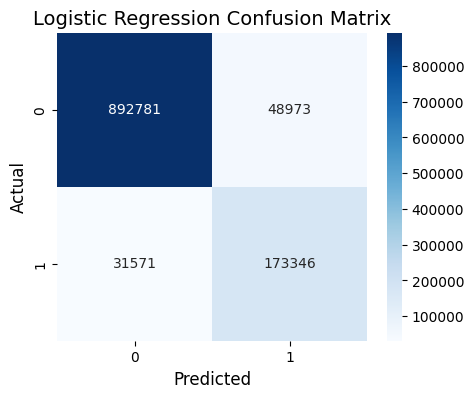

In [132]:
lr_pd = lr_preds.select("IS_DELAYED", "prediction").toPandas()

cm_lr = confusion_matrix(lr_pd["IS_DELAYED"], lr_pd["prediction"])

plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
xgb_pd = xgb_preds.select("IS_DELAYED", "prediction").toPandas()

cm_xgb = confusion_matrix(xgb_pd["IS_DELAYED"], xgb_pd["prediction"])

plt.figure(figsize=(5,4))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Greens")
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 9.5 Regression — Pandas / Sklearn (5% Sample)

> Predicts arrival delay minutes using pre-takeoff features + log/interaction transforms.


In [83]:
X_reg_train.columns

Index(['MONTH', 'DAY', 'DAY_OF_WEEK', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME',
       'DEPARTURE_DELAY', 'TAXI_OUT', 'SCHEDULED_TIME', 'DISTANCE',
       'SCHEDULED_ARRIVAL', 'DEP_HOUR'],
      dtype='object')

In [91]:
def run_reg_pipeline(name, model, param_grid, X_train, y_train, X_test, y_test):

    print(f"\n{'='*30} {name} {'='*30}")

    pipeline = SkPipeline([
        ('preprocessing', build_preprocessor()),
        ('model', model)
    ])

    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

    fixed_param_grid = {
        f"model__{k}": v for k, v in param_grid.items()
    }

    search = GridSearchCV(
        estimator=pipeline,
        param_grid=fixed_param_grid,
        cv=cv,
        scoring='r2',
        n_jobs=-1,
        verbose=1
    )

    search.fit(X_train, y_train)

    print(f"\nBest CV R²: {search.best_score_:.4f}")
    print(f"Best Params: {search.best_params_}")

    best_model = search.best_estimator_

    # Predictions
    y_train_pred = best_model.predict(X_train)
    y_test_pred  = best_model.predict(X_test)

    # Metrics
    print("\nTRAIN METRICS")
    print(f"R²   : {r2_score(y_train, y_train_pred):.4f}")
    print(f"RMSE : {np.sqrt(mean_squared_error(y_train, y_train_pred)):.2f}")

    print("\nTEST METRICS")
    print(f"R²   : {r2_score(y_test, y_test_pred):.4f}")
    print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_test_pred)):.2f}")

    return search.best_score_, best_model

In [92]:
results_reg = {}

# ── Linear Regression ────────────────────────────────────────────────────────
results_reg['LR'] = run_reg_pipeline(
    "Linear Regression",
    LinearRegression(),
    {},
    X_reg_train, y_reg_train, X_reg_test, y_reg_test
)

# ── HistGradientBoosting ─────────────────────────────────────────────────────
results_reg['HGB'] = run_reg_pipeline(
    "HistGradientBoosting",
    HistGradientBoostingRegressor(random_state=RANDOM_SEED),
    {
        'max_iter': [200],
        'max_depth': [5, 8],
        'learning_rate': [0.05, 0.1],
    },
    X_reg_train, y_reg_train, X_reg_test, y_reg_test
)

# ── XGBoost (replacement for GradientBoosting) ───────────────────────────────
results_reg['XGB'] = run_reg_pipeline(
    "XGBoost",
    XGBRegressor(
        random_state=RANDOM_SEED,
        n_jobs=-1,
        objective='reg:squarederror'
    ),
    {
        'n_estimators': [200],
        'max_depth': [4, 6],
        'learning_rate': [0.05, 0.1],
        'subsample': [0.8],
        'colsample_bytree': [0.8]
    },
    X_reg_train, y_reg_train, X_reg_test, y_reg_test
)


============================== Linear Regression ==============================
Fitting 5 folds for each of 1 candidates, totalling 5 fits

Best CV R²: 0.9215
Best Params: {}

TRAIN METRICS
R²   : 0.9216
RMSE : 10.78

TEST METRICS
R²   : 0.9198
RMSE : 10.73


### 9.6 Regression — PySpark MLlib (Full 5.8M Rows)


In [99]:
sdf_clean.columns

['MONTH',
 'DAY',
 'DAY_OF_WEEK',
 'AIRLINE',
 'FLIGHT_NUMBER',
 'ORIGIN_AIRPORT',
 'DESTINATION_AIRPORT',
 'SCHEDULED_DEPARTURE',
 'DEPARTURE_TIME',
 'DEPARTURE_DELAY',
 'TAXI_OUT',
 'WHEELS_OFF',
 'SCHEDULED_TIME',
 'ELAPSED_TIME',
 'AIR_TIME',
 'DISTANCE',
 'WHEELS_ON',
 'TAXI_IN',
 'SCHEDULED_ARRIVAL',
 'ARRIVAL_TIME',
 'ARRIVAL_DELAY',
 'DIVERTED',
 'CANCELLED',
 'CANCELLATION_REASON',
 'AIR_SYSTEM_DELAY',
 'SECURITY_DELAY',
 'AIRLINE_DELAY',
 'LATE_AIRCRAFT_DELAY',
 'WEATHER_DELAY']

In [114]:
SPARK_REG_COLS = [
    'MONTH', 'DAY', 'DAY_OF_WEEK',
    'SCHEDULED_DEPARTURE',
    'DEPARTURE_TIME',
    'DEPARTURE_DELAY',
    'TAXI_OUT',
    'SCHEDULED_TIME',
    'DISTANCE',
    'SCHEDULED_ARRIVAL'
]

sdf_ml = sdf_clean.select(*SPARK_CLF_COLS, "ARRIVAL_DELAY")

# sdf_ml = sdf_ml.withColumn(
#     "DEP_HOUR",
#     (F.col("SCHEDULED_DEPARTURE") / 100).cast("int")
# )

SPARK_ALL_COLS = SPARK_CLF_COLS

sdf_ml = sdf_ml.dropna()

for c in SPARK_ALL_COLS:
    sdf_ml = sdf_ml.withColumn(c, F.col(c).cast("double"))

assembler = VectorAssembler(
    inputCols=SPARK_ALL_COLS,
    outputCol="features"
)

sdf_ml = assembler.transform(sdf_ml)

train_df, test_df = sdf_ml.randomSplit([0.8, 0.2], seed=42)

print(f"Features: {train_df.columns}")

Features: ['MONTH', 'DAY', 'DAY_OF_WEEK', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'SCHEDULED_TIME', 'DISTANCE', 'SCHEDULED_ARRIVAL', 'ARRIVAL_DELAY', 'features']


In [120]:
train_df = train_df.drop("features") if "features" in train_df.columns else train_df
test_df = test_df.drop("features") if "features" in test_df.columns else test_df

In [122]:
xgb = SparkXGBRegressor(
    features_col="features",
    label_col="ARRIVAL_DELAY",
    num_round=150,
    max_depth=6,
    eta=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="rmse",
    num_workers=2,
    seed=42
)

pipeline = Pipeline(stages=[assembler, xgb])

rmse = RegressionEvaluator(labelCol="ARRIVAL_DELAY", metricName="rmse")
mae  = RegressionEvaluator(labelCol="ARRIVAL_DELAY", metricName="mae")
r2   = RegressionEvaluator(labelCol="ARRIVAL_DELAY", metricName="r2")


print("Training XGBoost...")
t0 = time.time()
model = pipeline.fit(train_df)
t1 = time.time() - t0

preds = model.transform(test_df)

print(f"\nTraining time: {t1:.1f}s")
print("RMSE:", rmse.evaluate(preds))
print("MAE :", mae.evaluate(preds))
print("R2  :", r2.evaluate(preds))

Training XGBoost...


Py4JJavaError: An error occurred while calling z:org.apache.spark.api.python.PythonRDD.collectAndServe.
: org.apache.spark.scheduler.BarrierJobSlotsNumberCheckFailed: [SPARK-24819]: Barrier execution mode does not allow run a barrier stage that requires more slots than the total number of slots in the cluster currently. Please init a new cluster with more resources(e.g. CPU, GPU) or repartition the input RDD(s) to reduce the number of slots required to run this barrier stage.
	at org.apache.spark.errors.SparkCoreErrors$.numPartitionsGreaterThanMaxNumConcurrentTasksError(SparkCoreErrors.scala:241)
	at org.apache.spark.scheduler.DAGScheduler.checkBarrierStageWithNumSlots(DAGScheduler.scala:577)
	at org.apache.spark.scheduler.DAGScheduler.createResultStage(DAGScheduler.scala:655)
	at org.apache.spark.scheduler.DAGScheduler.handleJobSubmitted(DAGScheduler.scala:1342)
	at org.apache.spark.scheduler.DAGSchedulerEventProcessLoop.doOnReceive(DAGScheduler.scala:3150)
	at org.apache.spark.schedu

### 9.7 Model Evaluation — Results, Plots & Feature Importance

─── Classification Results (Cross-Validation F1) ───────────────────────


,CV_F1
LR,0.916900


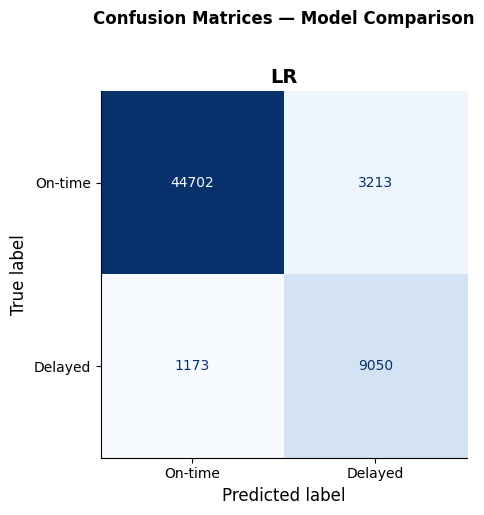

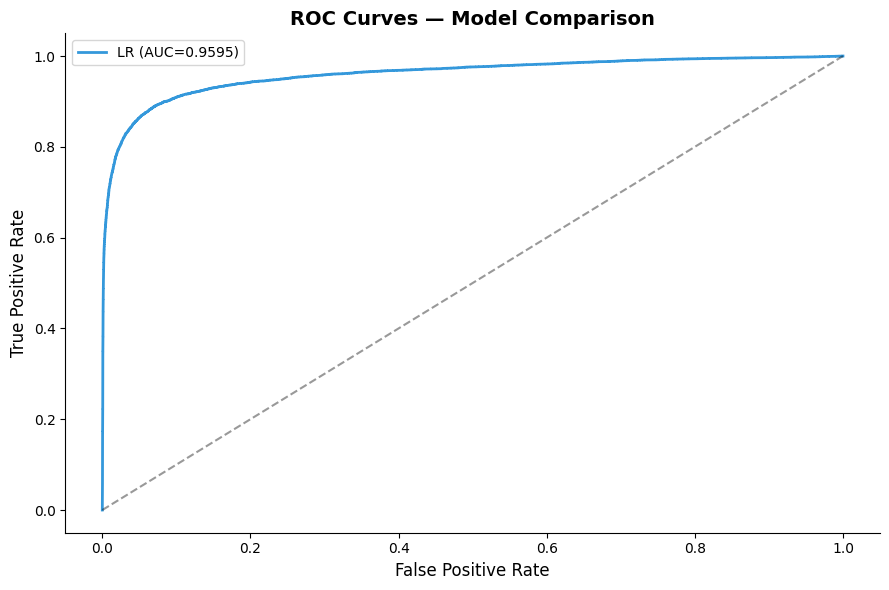

In [131]:
# ─────────────────────────────────────────────────────────────────────────────
# 1️⃣ Extract models + predictions
# ─────────────────────────────────────────────────────────────────────────────
models = {
    'LR': results_clf['LR'][1],
    'HGB': results_clf['HGB'][1],
    'XGB': results_clf['XGB'][1]
}

y_pred = {}
y_prob = {}

for name, model in models.items():
    y_pred[name] = model.predict(X_test)
    y_prob[name] = model.predict_proba(X_test)[:, 1]


# ─────────────────────────────────────────────────────────────────────────────
# 2️⃣ Classification results table (CV scores)
# ─────────────────────────────────────────────────────────────────────────────
clf_df = pd.DataFrame({
    name: {'CV_F1': results_clf[name][0]}
    for name in results_clf
}).T.round(4)

print('─── Classification Results (Cross-Validation F1) ───────────────────────')
display(clf_df.style.highlight_max(axis=0, color='#d4edda'))


# ─────────────────────────────────────────────────────────────────────────────
# 3️⃣ Confusion Matrices
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, name in zip(axes, ['LR', 'HGB', 'XGB']):
    cm = confusion_matrix(y_clf_test, y_pred[name])

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['On-time', 'Delayed']
    ).plot(ax=ax, cmap='Blues', colorbar=False)

    ax.set_title(name, fontweight='bold')

plt.suptitle('Confusion Matrices — Model Comparison', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# 4️⃣ ROC Curves
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

colors = {
    'LR': '#3498db',
    'HGB': '#e74c3c',
    'XGB': '#2ecc71'
}

for name in ['LR', 'HGB', 'XGB']:
    fpr, tpr, _ = roc_curve(y_clf_test, y_prob[name])
    auc = roc_auc_score(y_clf_test, y_prob[name])

    ax.plot(
        fpr, tpr,
        linewidth=2,
        color=colors[name],
        label=f'{name} (AUC={auc:.4f})'
    )

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Model Comparison', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()


# # ─────────────────────────────────────────────────────────────────────────────
# # 5️⃣ Feature Importance (HGB)
# # ─────────────────────────────────────────────────────────────────────────────
# hgb_model = models['HGB'].named_steps['model']

# fi_hgb = pd.Series(
#     hgb_model.feature_importances_,
#     index=CLF_COLS[:len(hgb_model.feature_importances_)]
# ).sort_values(ascending=False)

# fig, ax = plt.subplots(figsize=(14, 5))

# fi_hgb.head(15).plot(
#     kind='bar',
#     ax=ax,
#     color=sns.color_palette('viridis', 15)
# )

# ax.set_title('Feature Importance — HistGradientBoosting', fontweight='bold')
# ax.set_ylabel('Importance')
# ax.tick_params(axis='x', rotation=45)

# plt.tight_layout()
# plt.show()

─── Regression Results (Sklearn — sample) ────────────────────────────────


,R²
LR,0.922


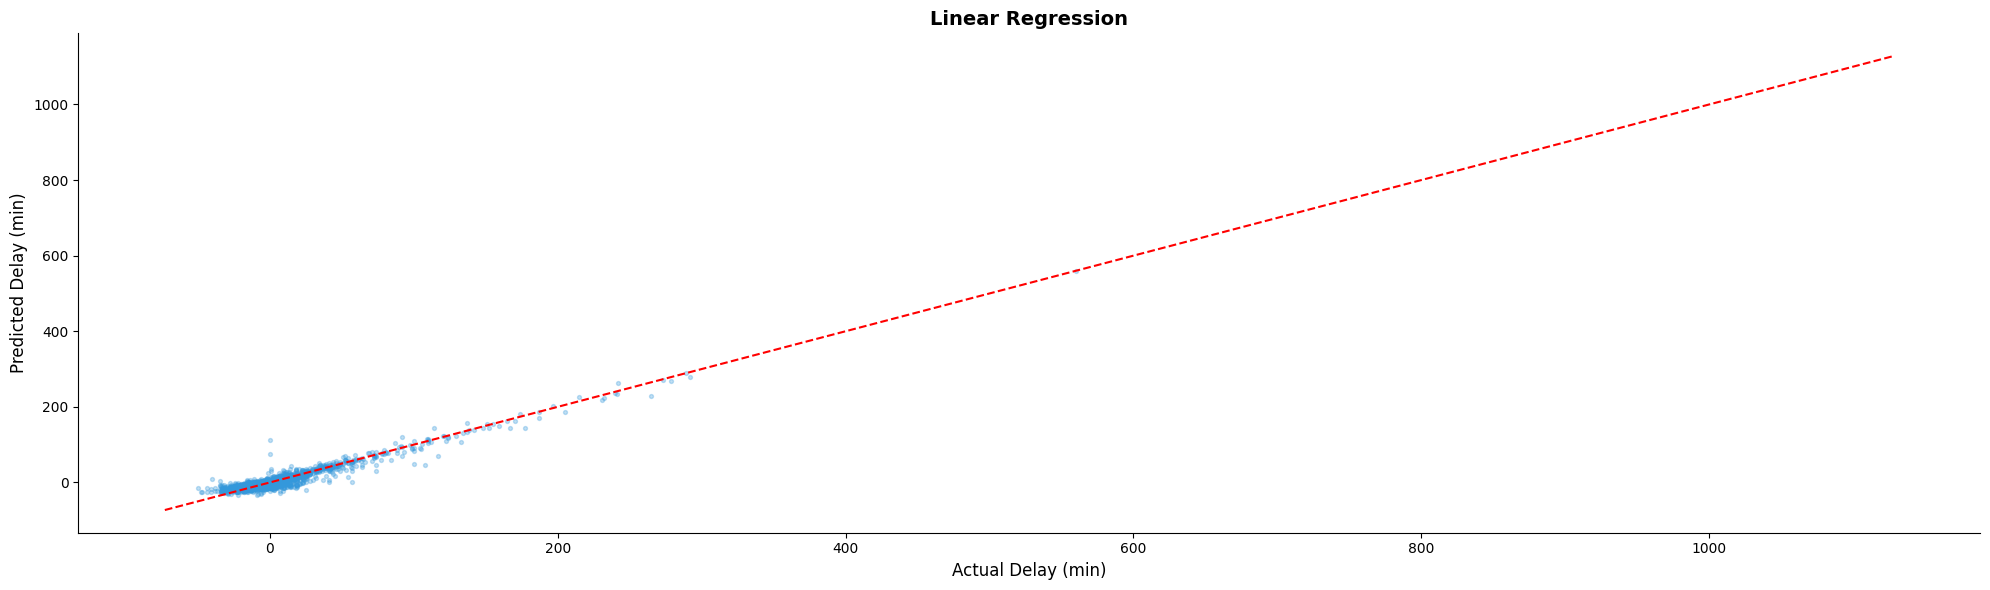

In [126]:
# ─────────────────────────────────────────────────────────────────────────────
# 1️⃣ Extract predictions from stored pipelines
# ─────────────────────────────────────────────────────────────────────────────
y_pred_lr_reg  = results_reg['LR'][1].predict(X_reg_test)
y_pred_hgb_reg = results_reg['HGB'][1].predict(X_reg_test)
y_pred_xgb_reg = results_reg['XGB'][1].predict(X_reg_test)

# ─────────────────────────────────────────────────────────────────────────────
# 2️⃣ Results table
# ─────────────────────────────────────────────────────────────────────────────
reg_df = pd.DataFrame({
    'LR':  results_reg['LR'][0],
    'HGB': results_reg['HGB'][0],
    'XGB': results_reg['XGB'][0],
}, index=['R²'])

print('─── Regression Results (Sklearn — sample) ────────────────────────────────')
display(reg_df.T.style.format('{:.3f}'))

# ─────────────────────────────────────────────────────────────────────────────
# 3️⃣ Actual vs Predicted scatter
# ─────────────────────────────────────────────────────────────────────────────
sample_n = min(2000, len(y_reg_test))
idx_s = np.random.choice(len(y_reg_test), sample_n, replace=False)

all_preds = np.concatenate([y_pred_lr_reg, y_pred_hgb_reg, y_pred_xgb_reg])
lim_lo = float(min(y_reg_test.min(), all_preds.min()))
lim_hi = float(max(y_reg_test.max(), all_preds.max()))

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

models = [
    (axes[0], y_pred_lr_reg,  '#3498db', 'Linear Regression'),
    (axes[1], y_pred_hgb_reg, '#9b59b6', 'HistGradientBoosting'),
    (axes[2], y_pred_xgb_reg, '#2ecc71', 'XGBoost')
]

for ax, y_p, color, title in models:
    ax.scatter(
        y_reg_test.values[idx_s],
        y_p[idx_s],
        alpha=0.3,
        s=8,
        color=color
    )

    ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi],
            'r--', linewidth=1.5)

    ax.set_xlabel('Actual Delay (min)')
    ax.set_ylabel('Predicted Delay (min)')
    ax.set_title(title, fontweight='bold')

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 4️⃣ Residual plot (best model: XGB)
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))

residuals = y_reg_test.values - y_pred_xgb_reg

ax.hist(residuals, bins=80, color='#2ecc71', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', linewidth=1.5, linestyle='--')

ax.set_title('XGBoost Regressor — Residual Distribution', fontweight='bold')
ax.set_xlabel('Residual (Actual − Predicted) in minutes')
ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()